# Data Prep

### Config

In [1]:
import io
import zipfile
import requests
import numpy as np
import pandas as pd

SCF_URL = "https://www.federalreserve.gov/econres/files/scf2022s.zip"
EXT_URL = "https://www.federalreserve.gov/econres/files/scfp2022s.zip"
RW_URL  = "https://www.federalreserve.gov/econres/files/scf2022rw1s.zip"

### Helper functions

In [2]:
def load_stata_from_zip(url: str) -> pd.DataFrame:
    """
    Download a ZIP archive from URL, find the first .dta file inside,
    read it into pandas, lowercase the columns, and return a df.
    """
    resp = requests.get(url, timeout=180)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        dta_files = [name for name in zf.namelist() if name.lower().endswith(".dta")]
        if not dta_files:
            raise ValueError(f"No .dta file found in archive: {url}")

        if len(dta_files) > 1:
            print(f"Warning: multiple .dta files found in {url}; using {dta_files[0]}")

        with zf.open(dta_files[0]) as f:
            df = pd.read_stata(f)

    df.columns = df.columns.str.lower()
    return df


def validate_structure(scf_df: pd.DataFrame, ext_df: pd.DataFrame, rw_df: pd.DataFrame) -> None:
    """
    Validate the assumptions used by the workflow.
    """
    if len(scf_df) != len(rw_df) * 5:
        raise ValueError(
            f"Expected len(scf_df) == len(rw_df) * 5, got {len(scf_df)} vs {len(rw_df)} * 5"
        )

    if len(scf_df) != len(ext_df):
        raise ValueError(
            f"Expected len(scf_df) == len(ext_df), got {len(scf_df)} vs {len(ext_df)}"
        )

    scf_ext_overlap = sorted(set(scf_df.columns).intersection(ext_df.columns))
    scf_rw_overlap = sorted(set(scf_df.columns).intersection(rw_df.columns))
    ext_rw_overlap = sorted(set(ext_df.columns).intersection(rw_df.columns))

    expected_overlap = ["y1", "yy1"]

    if scf_ext_overlap != expected_overlap:
        raise ValueError(f"Unexpected overlap scf/ext: {scf_ext_overlap}")

    if scf_rw_overlap != expected_overlap:
        raise ValueError(f"Unexpected overlap scf/rw: {scf_rw_overlap}")

    if ext_rw_overlap != expected_overlap:
        raise ValueError(f"Unexpected overlap ext/rw: {ext_rw_overlap}")


def build_replicate_weights(rw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build final replicate weights:
    wgt{i} = wt1b{i} * mm{i} for i=1..999
    Keep only yy1 + wgt1..wgt999.
    """
    rw_df = rw_df.copy()

    if "y1" in rw_df.columns:
        rw_df = rw_df.drop(columns=["y1"])

    rw_df = rw_df.fillna(0)

    wt_cols = [f"wt1b{i}" for i in range(1, 1000)]
    mm_cols = [f"mm{i}" for i in range(1, 1000)]
    wgt_cols = [f"wgt{i}" for i in range(1, 1000)]

    missing_wt = [c for c in wt_cols if c not in rw_df.columns]
    missing_mm = [c for c in mm_cols if c not in rw_df.columns]

    if missing_wt or missing_mm:
        raise KeyError(
            f"Missing expected replicate-weight columns. "
            f"Missing wt: {missing_wt[:5]}{'...' if len(missing_wt) > 5 else ''}, "
            f"Missing mm: {missing_mm[:5]}{'...' if len(missing_mm) > 5 else ''}"
        )

    wgt_values = rw_df[wt_cols].to_numpy() * rw_df[mm_cols].to_numpy()
    wgt_df = pd.DataFrame(wgt_values, columns=wgt_cols, index=rw_df.index)

    out = pd.concat([rw_df[["yy1"]].copy(), wgt_df], axis=1)
    out = out.sort_values("yy1").reset_index(drop=True)

    return out


def build_implicates_and_merge(scf_df: pd.DataFrame, ext_df: pd.DataFrame) -> list[pd.DataFrame]:
    """
    Split SCF into 5 implicates based on the last character of y1,
    then merge each implicate with ext_df on y1 and yy1.
    """
    scf_df = scf_df.copy()
    scf_df["five"] = 5

    # Preserve original value and derive implicate key robustly
    y1_str = scf_df["y1"].astype(str).str.strip()
    scf_df["_implicate"] = y1_str.str[-1]

    implicates = []
    for i in range(1, 6):
        imp = scf_df.loc[scf_df["_implicate"] == str(i)].copy()
        imp = imp.drop(columns=["_implicate"])
        merged = imp.merge(ext_df, on=["y1", "yy1"], how="inner")
        merged = merged.sort_values("yy1").reset_index(drop=True)
        implicates.append(merged)

    return implicates

### Data import and merge

In [3]:
print("Downloading SCF files...")
scf_df = load_stata_from_zip(SCF_URL)
ext_df = load_stata_from_zip(EXT_URL)
rw_df = load_stata_from_zip(RW_URL)

print("Loaded:")
print("  scf_df:", scf_df.shape)
print("  ext_df:", ext_df.shape)
print("  rw_df :", rw_df.shape)

print("\nValidating structure...")
validate_structure(scf_df, ext_df, rw_df)
print("Structure checks passed.")

print("\nBuilding replicate weights...")
scf_rw_df = build_replicate_weights(rw_df)
print("  scf_rw_df:", scf_rw_df.shape)

print("\nBuilding implicates and merging with extract...")
scf_list = build_implicates_and_merge(scf_df, ext_df)

for idx, df in enumerate(scf_list, start=1):
    print(f"  implicate {idx}: {df.shape}")

# Optional sanity check
total_rows = sum(len(df) for df in scf_list)
if total_rows != len(scf_df):
    raise ValueError(f"Expected total implicate rows to equal scf_df rows, got {total_rows} vs {len(scf_df)}")

print("\nCombining implicates...")
scf_list_combined = pd.concat(scf_list, ignore_index=True)
print("  scf_list_combined:", scf_list_combined.shape)

Loaded:
  scf_df: (22975, 5473)
  ext_df: (22975, 357)
  rw_df : (4595, 2000)

Validating structure...
Structure checks passed.

Building replicate weights...
  scf_rw_df: (4595, 1000)

Building implicates and merging with extract...
  implicate 1: (4595, 5829)
  implicate 2: (4595, 5829)
  implicate 3: (4595, 5829)
  implicate 4: (4595, 5829)
  implicate 5: (4595, 5829)

Combining implicates...
  scf_list_combined: (22975, 5829)


In [4]:
scf_list_combined

,j7398,j7578,j7579,j7019,j7020,j7001,j7050,j8020,j8021,j5908,...,nwcat,inccat,assetcat,ninccat,ninc2cat,nwpctlecat,incpctlecat,nincpctlecat,incqrtcat,nincqrtcat
0,0,0,0,8,8,8,0,0,0,0,...,4,2,4,2,1,8,3,3,2,1
1,0,0,0,8,8,0,0,0,0,0,...,4,5,5,5,2,8,9,9,4,4
2,0,0,0,8,8,0,0,0,0,0,...,5,6,6,6,3,12,11,11,4,4
3,0,0,0,8,8,0,0,0,0,0,...,5,5,6,4,2,10,9,8,4,4
4,0,0,0,8,8,0,0,0,0,0,...,1,3,1,2,1,2,5,4,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22970,0,0,0,8,8,0,0,0,0,0,...,5,6,6,6,3,11,12,12,4,4
22971,0,0,0,8,8,0,0,0,0,0,...,3,5,4,5,2,7,9,9,4,4
22972,0,0,0,8,8,0,0,0,0,0,...,1,5,1,3,2,1,9,6,4,3
22973,0,0,0,8,8,0,0,0,0,0,...,3,3,3,3,1,6,5,5,2,2


In [5]:
print([col for col in scf_list_combined.columns if not col.startswith(("j", "x"))][:50])

['yy1', 'y1', 'five', 'wgt', 'hhsex', 'age', 'agecl', 'educ', 'edcl', 'married', 'kids', 'lf', 'lifecl', 'famstruct', 'racecl', 'racecl4', 'racecl5', 'racecl_ex', 'race', 'occat1', 'occat2', 'indcat', 'foodhome', 'foodaway', 'fooddelv', 'rent', 'income', 'wageinc', 'bussefarminc', 'intdivinc', 'kginc', 'ssretinc', 'transfothinc', 'penacctwd', 'norminc', 'wsaved', 'saved', 'savres1', 'savres2', 'savres3', 'savres4', 'savres5', 'savres6', 'savres7', 'savres8', 'savres9', 'spendmor', 'spendless', 'expenshilo', 'late']


# Constructing Latent Risk Tolerance Score using PCA

This will act as a proxy for a risk tolerance score, using someone's tendencies to spend more, save less, and perceive their income relative to their expenses to infer willingness to take financial risk, which can then be mapped to observable household characteristics through a RandomForest. We construct a latent risk tolerance score using survey-based behavioral indicators that capture individuals’ willingness to spend beyond their means, preference for saving, and perceived financial constraints.

In [37]:
import sklearn

df = scf_list_combined.copy()

df["spendless"] = -df["spendless"] # Flipping sign of variable that indiates risk aversion

risk_vars = [
    "spendmor", # Spending more than your income, you are willing to spend beyond your means?
    "spendless", # Spending less than your income, do you exhibit more conservative behavior?
    "expenshilo", # Measures how people feel about their financial situation
    "x6556", # Percentage of IRA/Keogh account that is in stocks
    "x3023", # Self-reported score on satisfaction with current or expected retirement income
    "x7562", # Self-reported score on how much research a survey respondent does when making saving and investment decisions
]

X_risk = df[risk_vars].copy()

# Fill missing values
X_risk = X_risk.fillna(0)

In [38]:
# Standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_risk)

In [39]:
# Run PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
risk_component = pca.fit_transform(X_scaled)

# Weighted PCA with survey weights, less expressive but more accurate. Expressiveness is important for a dashboard product:

# Get weights aligned with X_risk
# weights = df.loc[X_risk.index, "wgt"].values

# Normalize weights
# weights = weights / np.mean(weights)

# Apply sqrt weighting
# X_weighted = X_scaled * np.sqrt(weights[:, None])

# pca = PCA(n_components=1)
# risk_component = pca.fit_transform(X_weighted)

In [40]:
# Convert to score from 1-10, fill in risk_score for use in RandomForest

import numpy as np

df["risk_score"] = risk_component.flatten()

# Scale to 0–10
df["risk_score"] = 10 * (df["risk_score"] - df["risk_score"].min()) / (
    df["risk_score"].max() - df["risk_score"].min()
)

In [41]:
import pandas as pd

loadings = pd.Series(
    pca.components_[0],
    index=risk_vars
)

print(loadings.sort_values(ascending=False))

x3023         0.616877
x6556         0.504576
expenshilo    0.378193
x7562         0.365936
spendmor      0.136624
spendless    -0.263174
dtype: float64


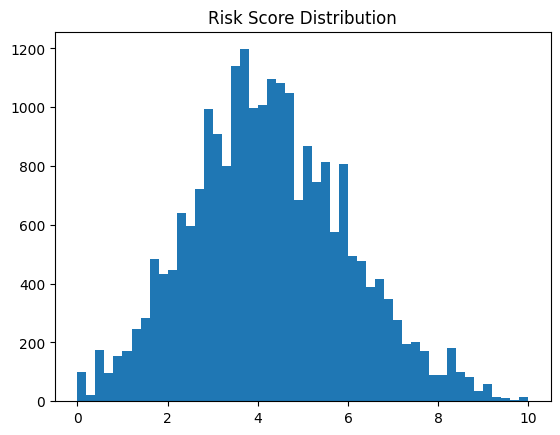

In [42]:
import matplotlib.pyplot as plt

plt.hist(df["risk_score"], bins=50)
plt.title("Risk Score Distribution")
plt.show()

# Random Forest

### Imports and dataframe

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


model_df = df.copy()

### Define target, weights, and feature columns

In [44]:
target_col = "risk_score"
weight_col = "wgt"

feature_cols = [
    "age",
    "educ",
    "kids",
    "married",
    "income", #value
    "wageinc", #value
    "networth", #value
    "asset", # value
    "debt", # value
    "liq", # value
    "fin", # value
    "houses", #value
    "vehic", #value
    "wsaved", # 1: spending exceeds inc, 2: spending equals inc, 3: spending less than inc... which category do you fall into?
    "saved" # did you spend less than your income? binary
]


feature_cols = [c for c in feature_cols if c in model_df.columns]

print("Features being used:")
print(feature_cols)

Features being used:
['age', 'educ', 'kids', 'married', 'income', 'wageinc', 'networth', 'asset', 'debt', 'liq', 'fin', 'houses', 'vehic', 'wsaved', 'saved']


### Keep needed columns, drop rows with missing target/weights

In [45]:
keep_cols = feature_cols + [target_col, weight_col]
model_df = model_df[keep_cols].copy()

model_df = model_df.dropna(subset=[target_col, weight_col])

# Remove nonpositive weights just to be safe
model_df = model_df[model_df[weight_col] > 0].copy()

### Train/test/weights split

In [46]:
# Split X, y, weights
X = model_df[feature_cols].copy()
y = model_df[target_col].copy()
sample_weight = model_df[weight_col].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("\nNumeric features:")
print(numeric_features)

# Should be none
print("\nCategorical features:")
print(categorical_features)

# Split with weights
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weight,
    test_size=0.2,
    random_state=42
)


Numeric features:
['age', 'educ', 'kids', 'married', 'income', 'wageinc', 'networth', 'asset', 'debt', 'liq', 'fin', 'houses', 'vehic', 'wsaved', 'saved']

Categorical features:
[]


### Preprocessing and Random Forest fit

In [47]:
# Preprocessing

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

# Weighted Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rf", rf)
])

# To pass sample_weight into the RandomForest inside a Pipeline, use the pipeline step name + __sample_weight
model.fit(X_train, y_train, rf__sample_weight=w_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'educ', 'kids',
                                                   'married', 'income',
                                                   'wageinc', 'networth',
                                                   'asset', 'debt', 'liq',
                                                   'fin', 'houses', 'vehic',
                                                   'wsaved', 'saved'])])),
                ('rf',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=10,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])

### Prediction and Evaluation

In [48]:
# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


# Weighted evaluation
def weighted_rmse(y_true, y_pred, sample_weight):
    return np.sqrt(mean_squared_error(y_true, y_pred, sample_weight=sample_weight))

train_rmse = weighted_rmse(y_train, y_pred_train, w_train)
test_rmse = weighted_rmse(y_test, y_pred_test, w_test)

train_r2 = r2_score(y_train, y_pred_train, sample_weight=w_train)
test_r2 = r2_score(y_test, y_pred_test, sample_weight=w_test)

print("\nModel Performance")
print("-----------------")
print(f"Train Weighted RMSE: {train_rmse:.4f}")
print(f"Test  Weighted RMSE: {test_rmse:.4f}")
print(f"Train Weighted R^2 : {train_r2:.4f}")
print(f"Test  Weighted R^2 : {test_r2:.4f}")


Model Performance
-----------------
Train Weighted RMSE: 0.7647
Test  Weighted RMSE: 0.8875
Train Weighted R^2 : 0.7660
Test  Weighted R^2 : 0.6799


### Feature Importance

In [49]:
all_feature_names = numeric_features

importances = model.named_steps["rf"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop Feature Importances")
print(feature_importance_df.head(16))


# Inspect prediction distribution
print("\nPrediction summary:")
print(pd.Series(y_pred_test).describe())



Top Feature Importances
     feature  importance
10       fin    0.370632
9        liq    0.082051
0        age    0.074381
4     income    0.062685
8       debt    0.057119
6   networth    0.054418
12     vehic    0.053506
13    wsaved    0.043274
7      asset    0.042673
1       educ    0.039931
5    wageinc    0.039717
11    houses    0.039688
14     saved    0.018809
2       kids    0.013896
3    married    0.007221

Prediction summary:
count    4595.000000
mean        4.239022
std         1.199701
min         1.154486
25%         3.305369
50%         4.092693
75%         5.117619
max         8.096733
dtype: float64


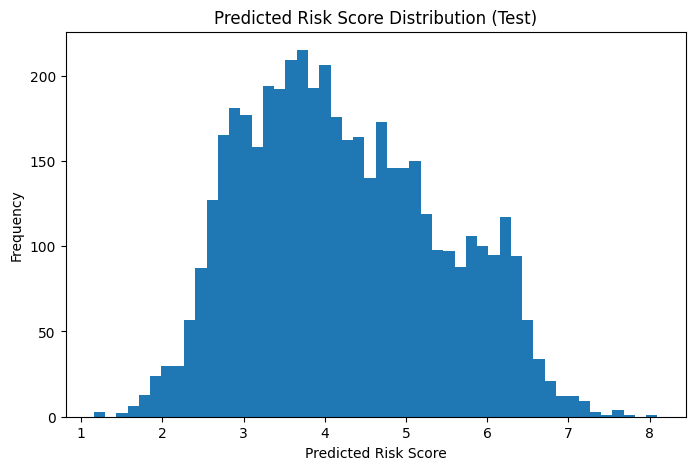

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y_pred_test, bins=50)
plt.title("Predicted Risk Score Distribution (Test)")
plt.xlabel("Predicted Risk Score")
plt.ylabel("Frequency")
plt.show()

In [23]:
a = df[feature_cols]
a

,age,educ,kids,married,income,wageinc,networth,asset,debt,liq,fin,houses,vehic,wsaved,saved
0,70,9,2,2,3.880473e+04,0.000000,762100.0,957100.0,195000,13100,258100,674000.0,25000,3,1
1,46,12,0,2,2.248297e+05,9836.297595,721800.0,1240500.0,518700,40500,140500,580000.0,60000,3,1
2,68,14,0,1,4.453357e+05,0.000000,43597590.0,61177590.0,17580000,10890,60492890,629000.0,40700,3,1
3,74,12,0,2,1.524086e+05,0.000000,2203000.0,2203000.0,0,164000,2163000,0.0,0,3,1
4,19,8,0,1,5.620741e+04,57288.326653,4100.0,15100.0,11000,1100,1100,0.0,14000,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22970,55,14,2,1,1.869977e+06,0.000000,6727000.0,7310000.0,583000,8000,3342000,1900000.0,118000,3,1
22971,50,11,0,1,1.567322e+05,156732.214429,346250.0,497000.0,150750,4000,252000,149000.0,96000,2,0
22972,31,13,0,2,1.718650e+05,65935.621242,-428650.0,980.0,429630,210,980,0.0,0,1,0
22973,56,9,0,2,6.053106e+04,60531.062124,224190.0,289340.0,65150,940,60340,202000.0,27000,3,1


In [24]:
a.describe()

,age,educ,kids,married,income,wageinc,networth,asset,debt,liq,fin,houses,vehic,wsaved,saved
count,22975.000000,22975.000000,22975.000000,22975.000000,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,2.297500e+04,22975.000000,22975.000000
mean,54.468988,10.328400,0.738629,1.367791,1.592855e+06,1.765788e+05,1.995640e+07,2.031705e+07,3.606429e+05,7.656218e+05,8.455668e+06,9.689703e+05,1.441208e+05,2.460370,0.615930
std,16.189081,2.815743,1.108022,0.482215,1.244271e+07,9.057205e+05,1.101707e+08,1.109256e+08,2.544356e+06,8.068051e+06,6.479996e+07,3.219532e+06,1.306187e+06,0.748047,0.486385
min,18.000000,-1.000000,0.000000,1.000000,0.000000e+00,-1.080912e+00,-5.555000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000
25%,42.000000,8.000000,0.000000,1.000000,4.215556e+04,0.000000e+00,3.590750e+04,6.385000e+04,0.000000e+00,1.930000e+03,5.335000e+03,0.000000e+00,9.500000e+03,2.000000,0.000000
50%,56.000000,11.000000,0.000000,1.000000,9.403933e+04,4.539830e+04,3.845000e+05,5.398000e+05,2.900000e+04,1.450000e+04,9.550000e+04,2.620000e+05,2.800000e+04,3.000000,1.000000
75%,67.000000,12.000000,1.000000,2.000000,2.648234e+05,1.286285e+05,2.476105e+06,2.716900e+06,2.170000e+05,9.800000e+04,1.017015e+06,7.500000e+05,6.100000e+04,3.000000,1.000000
max,95.000000,14.000000,10.000000,2.000000,4.582309e+08,3.013582e+07,2.387781e+09,2.387781e+09,1.319900e+08,2.676600e+08,2.119722e+09,1.132300e+08,3.870100e+07,3.000000,1.000000
